In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from importlib import reload

import robust_filter
import parameter_estimation

reload(robust_filter)
reload(parameter_estimation)

from data_processing import daily_stock_variance
from robust_filter import Filter, score_func, kalman_func
from parameter_estimation import generate_param_grid, grid_search

Data preparation

In [2]:
ROOT = Path.cwd()
PROJECT_ROOT = ROOT
DATA_DIR = PROJECT_ROOT / "data"
DATA_PATH = DATA_DIR / "bin201901.csv"
DATA_PATH

WindowsPath('c:/Users/chris/VSCodeProjects/robust-filtering/data/bin201901.csv')

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df_subset = df[df["stock"] == "AAPL"]
df_subset.head()

,date,time,stock,trade,orderFlow,hidden,auction,mid,midEnd,spread,effSpread,lobImb,effLobImb,trdLiq,ofLiq,depth,nbEvents,nbHidden,nbTrades
6627,2019-01-02,09:30:00,AAPL,-11855,-14141,12397,419249,154.915,154.755,0.055,0.156354,0.866667,0.261039,18657,68751,277.6250,8,1,2
6628,2019-01-02,09:30:10,AAPL,527,3346,4579,0,154.640,154.645,0.070,0.055760,0.000000,-0.659986,11359,42698,313.8571,7,1,2
6629,2019-01-02,09:30:20,AAPL,-2979,7161,1765,0,154.595,154.605,0.045,0.041798,0.333333,-0.010202,6573,78475,337.6250,8,1,2
6630,2019-01-02,09:30:30,AAPL,5120,12162,1663,0,154.600,154.620,0.010,0.015000,0.666667,0.703877,7322,106242,897.1111,9,1,2
6631,2019-01-02,09:30:40,AAPL,8889,29297,1038,0,154.885,154.875,0.035,0.029257,0.760000,0.640284,12651,126539,831.2500,8,1,2


In [5]:
# Compute intraday variance per day per stock
var_df = daily_stock_variance(
    df_subset, date_col="date", stock_col="stock", value_col="mid"
)
var_df.head(10)

,date,stock,mid_var
0,2019-01-02,AAPL,1.254937
1,2019-01-03,AAPL,0.831683
2,2019-01-04,AAPL,0.968374
3,2019-01-07,AAPL,0.340471
4,2019-01-08,AAPL,0.669532
5,2019-01-09,AAPL,0.236284
6,2019-01-10,AAPL,0.370574
7,2019-01-11,AAPL,0.182443
8,2019-01-14,AAPL,0.060622
9,2019-01-15,AAPL,0.376290


Real data: Intraday variance observations

In [6]:
# Extract variance observations as list (mean variance across all days)
y = var_df["mid_var"].values.tolist()
N = len(y)

print(f"Number of observations: {N}")
print(f"Observation mean: {np.mean(y):.6f}")
print(f"Observation std: {np.std(y):.6f}")
print(f"Observation min: {np.min(y):.6f}, max: {np.max(y):.6f}")
print(f"First 5 observations: {y[:5]}")

Number of observations: 21
Observation mean: 0.560049
Observation std: 0.426123
Observation min: 0.060622, max: 1.898497
First 5 observations: [1.254937433535907, 0.8316834178350951, 0.9683738066683377, 0.34047129514672353, 0.6695322685933905]


Parameter estimation

In [7]:
# Parameter grid for actual variance data
# Adjust ranges based on observed variance statistics
sigma_obs = np.std(y)
param_grid = {
    "nu": np.arange(4, 15, 1),  # Degrees of freedom for Student-t
    "sigma": np.linspace(
        sigma_obs * 0.2, sigma_obs * 1.5, 10
    ),  # Measurement noise scale
    "phi": np.linspace(0.5, 0.99, 10),  # State persistence (AR(1) coefficient)
    "kappa": np.linspace(0.5, 0.99, 10),  # Measurement update gain
}
param_dicts = generate_param_grid(param_grid)
print(f"Generated {len(param_dicts)} parameter combinations for grid search")

Generated 11000 parameter combinations for grid search


In [8]:
# Grid search for score filter (robust to outliers)
print("Grid search for Score filter...")
best_params_score = grid_search(
    y, mu_0=np.median(y), param_dicts=param_dicts, func=score_func, dist="student"
)
print("✓ Score filter grid search completed")
print(f"  Best params: {best_params_score}")

Grid search for Score filter...
✓ Score filter grid search completed
  Best params: {'nu': np.int64(6), 'sigma': np.float64(0.331429139680409), 'phi': np.float64(0.99), 'kappa': np.float64(0.5544444444444444)}


In [9]:
# Fit score filter with best parameters
score_filter = Filter(mu_0=np.median(y), param_dict=best_params_score, func=score_func)
score_filter.update(y)
print(
    f"✓ Score filter fitted, state range: [{np.min(score_filter.mu):.6f}, {np.max(score_filter.mu):.6f}]"
)

✓ Score filter fitted, state range: [0.167438, 0.840335]


In [10]:
# Grid search for Kalman filter (Gaussian residuals) - only phi, kappa, sigma
param_grid_kalman = {
    "phi": np.linspace(0.5, 0.99, 10),
    "kappa": np.linspace(0.5, 0.99, 10),
    "sigma": np.linspace(
        sigma_obs * 0.2, sigma_obs * 1.5, 10
    ),  # Measurement noise scale

}
param_dicts_kalman = generate_param_grid(param_grid_kalman)

print("Grid search for Kalman filter...")
best_params_kalman = grid_search(
    y, mu_0=np.median(y), param_dicts=param_dicts_kalman, func=kalman_func, dist="norm"
)
print(f"✓ Kalman filter grid search completed")
print(f"  Best params: {best_params_kalman}")

Grid search for Kalman filter...
✓ Kalman filter grid search completed
  Best params: {'phi': np.float64(0.99), 'kappa': np.float64(0.5), 'sigma': np.float64(0.45453139156170375)}


In [11]:
# Fit Kalman filter with best parameters
kalman_filter = Filter(mu_0=np.median(y), param_dict=best_params_kalman)
kalman_filter.update(y)
print(
    f"✓ Kalman filter fitted, state range: [{np.min(kalman_filter.mu):.6f}, {np.max(kalman_filter.mu):.6f}]"
)

✓ Kalman filter fitted, state range: [0.169758, 1.215860]


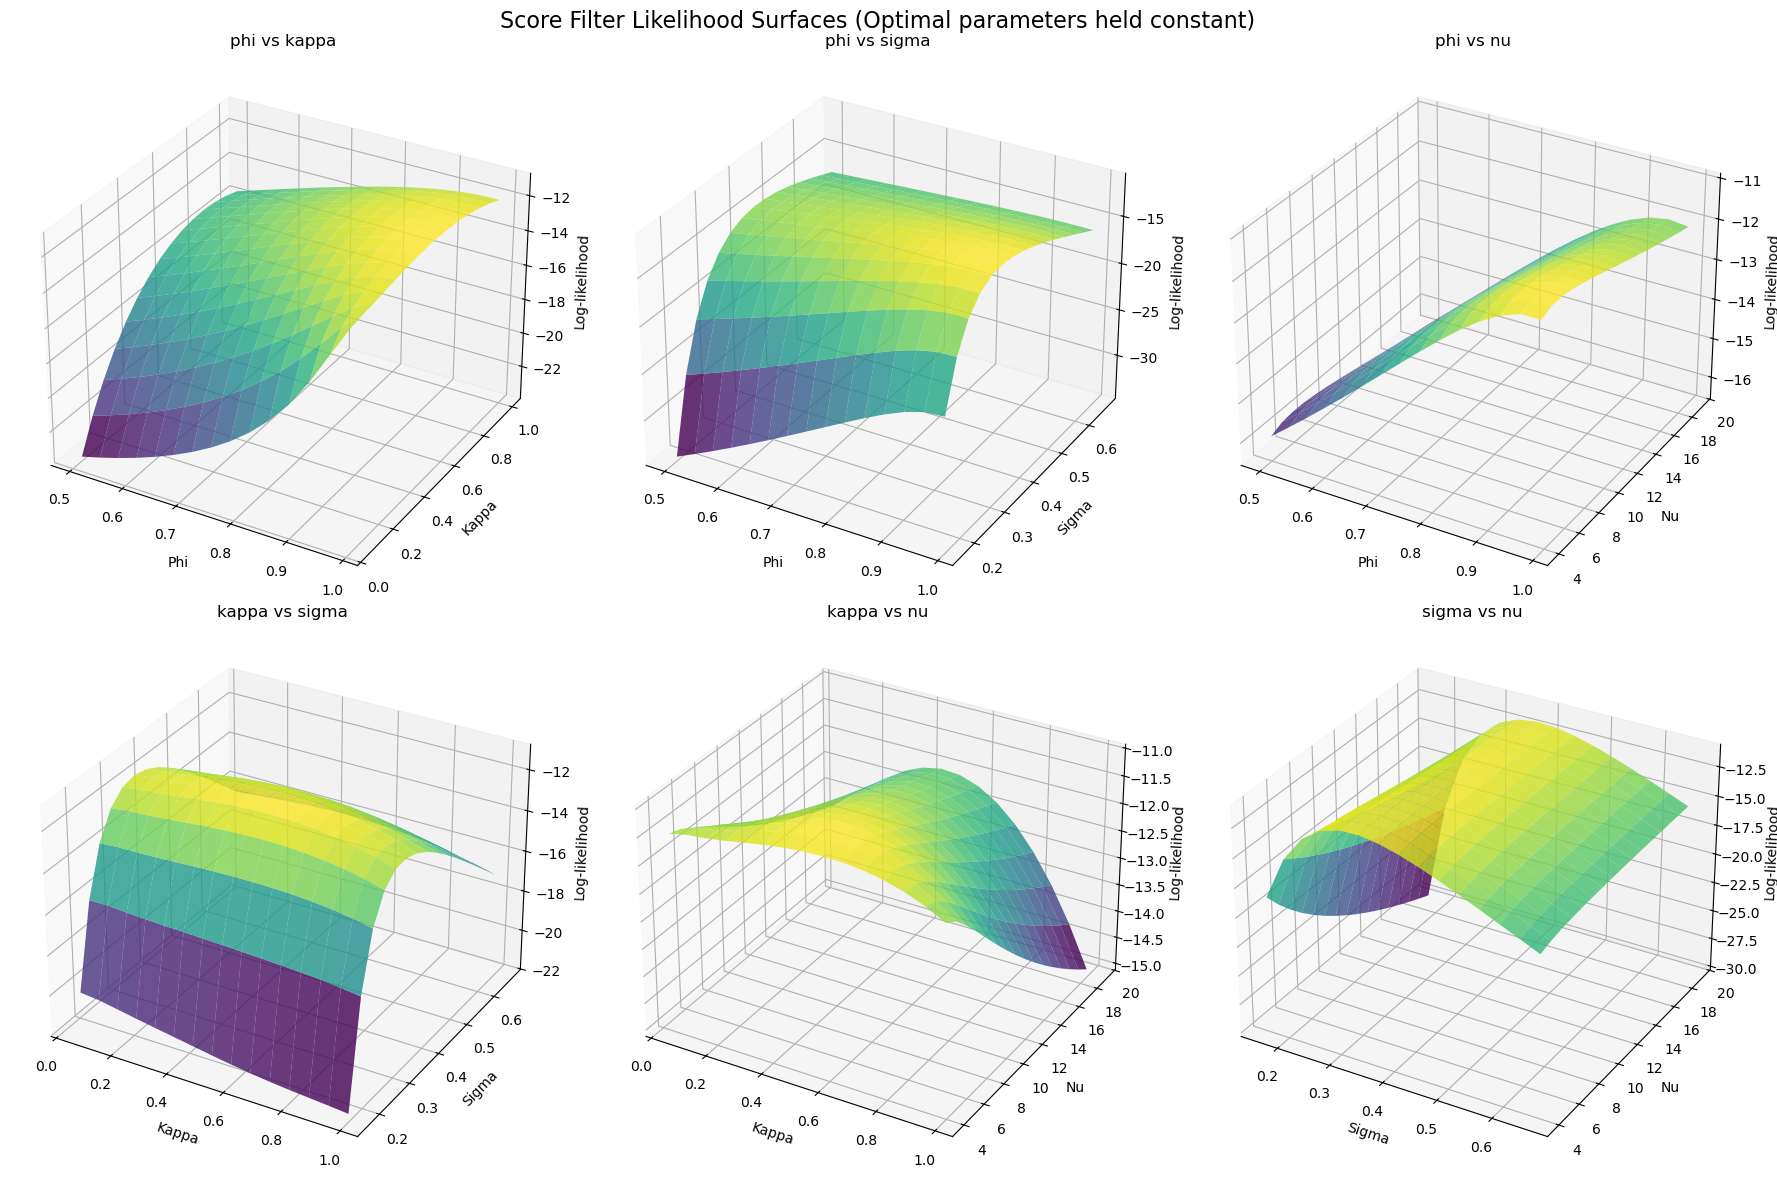

In [12]:
# Likelihood surface: Score filter
from parameter_estimation import log_likelihood
import itertools

# Create grid for each parameter based on their ranges in param_grid (or centered around best_params)
grids = {
    "phi": np.linspace(0.5, 0.99, 15),
    "kappa": np.linspace(0.05, 0.99, 15),
    "sigma": np.linspace(best_params_score["sigma"] * 0.5, best_params_score["sigma"] * 2.0, 15),
    "nu": np.arange(4, 20, 1)
}

pairs = list(itertools.combinations(grids.keys(), 2))

fig = plt.figure(figsize=(18, 12))
fig.suptitle("Score Filter Likelihood Surfaces (Optimal parameters held constant)", fontsize=16)

for idx, (p1, p2) in enumerate(pairs):
    ax = fig.add_subplot(2, 3, idx+1, projection='3d')
    X, Y = np.meshgrid(grids[p1], grids[p2])
    Z = np.zeros_like(X, dtype=float)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            # Set fixed params to optimal
            param_dict = best_params_score.copy()
            # Override varying params
            param_dict[p1] = X[i, j]
            param_dict[p2] = Y[i, j]
            
            filt = Filter(mu_0=np.median(y), param_dict=param_dict, func=score_func)
            filt.update(y)
            Z[i, j] = log_likelihood(filt.mu_prior, y, param_dict, dist="student")
            
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.8, edgecolor="none")
    ax.set_xlabel(p1.capitalize())
    ax.set_ylabel(p2.capitalize())
    ax.set_zlabel("Log-likelihood")
    ax.set_title(f"{p1} vs {p2}")

plt.tight_layout()
plt.show()

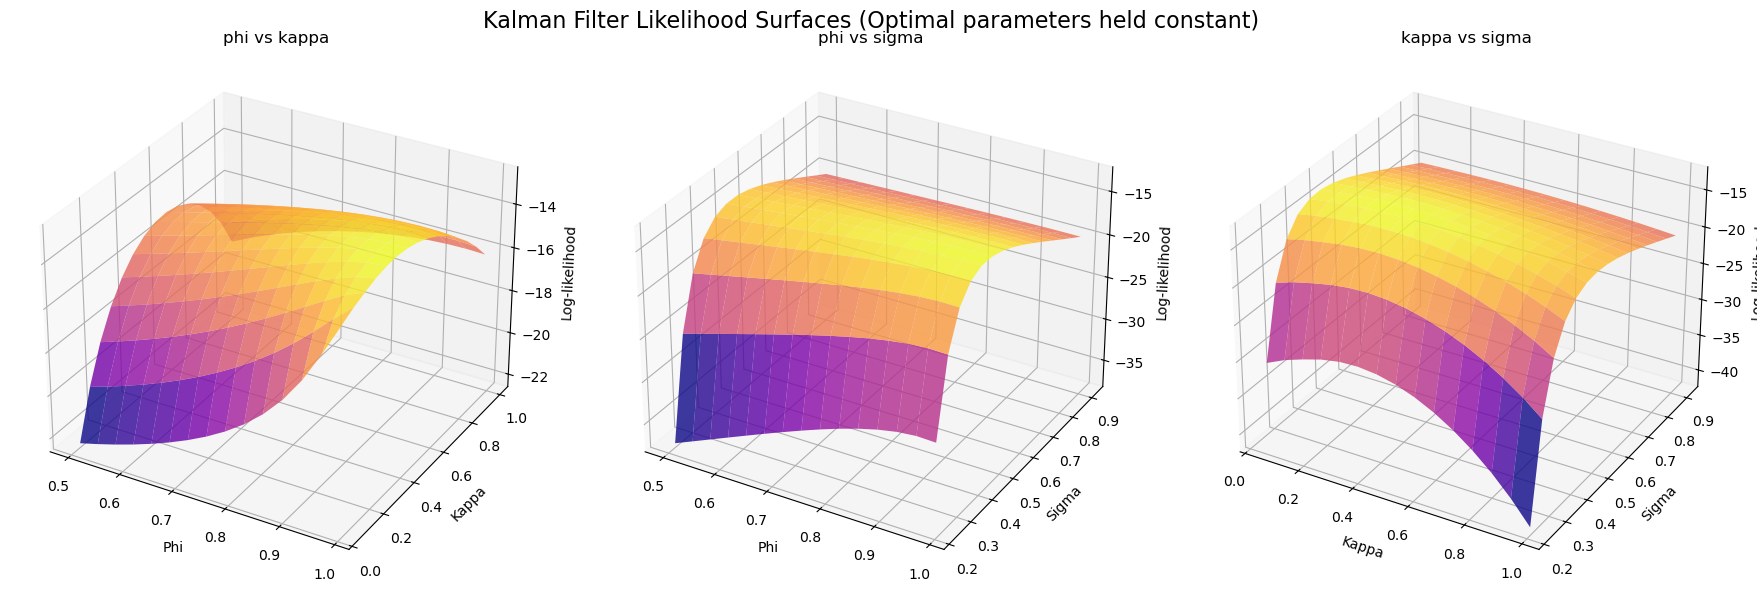

In [13]:
# Likelihood surface: Kalman filter

grids_k = {
    "phi": np.linspace(0.5, 0.99, 15),
    "kappa": np.linspace(0.05, 0.99, 15),
    "sigma": np.linspace(best_params_kalman["sigma"] * 0.5, best_params_kalman["sigma"] * 2.0, 15),
}

pairs_k = list(itertools.combinations(grids_k.keys(), 2))

fig = plt.figure(figsize=(18, 6))
fig.suptitle("Kalman Filter Likelihood Surfaces (Optimal parameters held constant)", fontsize=16)

for idx, (p1, p2) in enumerate(pairs_k):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    X, Y = np.meshgrid(grids_k[p1], grids_k[p2])
    Z = np.zeros_like(X, dtype=float)
    
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            param_dict = best_params_kalman.copy()
            param_dict[p1] = X[i, j]
            param_dict[p2] = Y[i, j]
            
            filt = Filter(mu_0=np.median(y), param_dict=param_dict, func=kalman_func)
            filt.update(y)
            Z[i, j] = log_likelihood(filt.mu_prior, y, param_dict, dist="norm")
            
    ax.plot_surface(X, Y, Z, cmap="plasma", alpha=0.8, edgecolor="none")
    ax.set_xlabel(p1.capitalize())
    ax.set_ylabel(p2.capitalize())
    ax.set_zlabel("Log-likelihood")
    ax.set_title(f"{p1} vs {p2}")

plt.tight_layout()
plt.show()

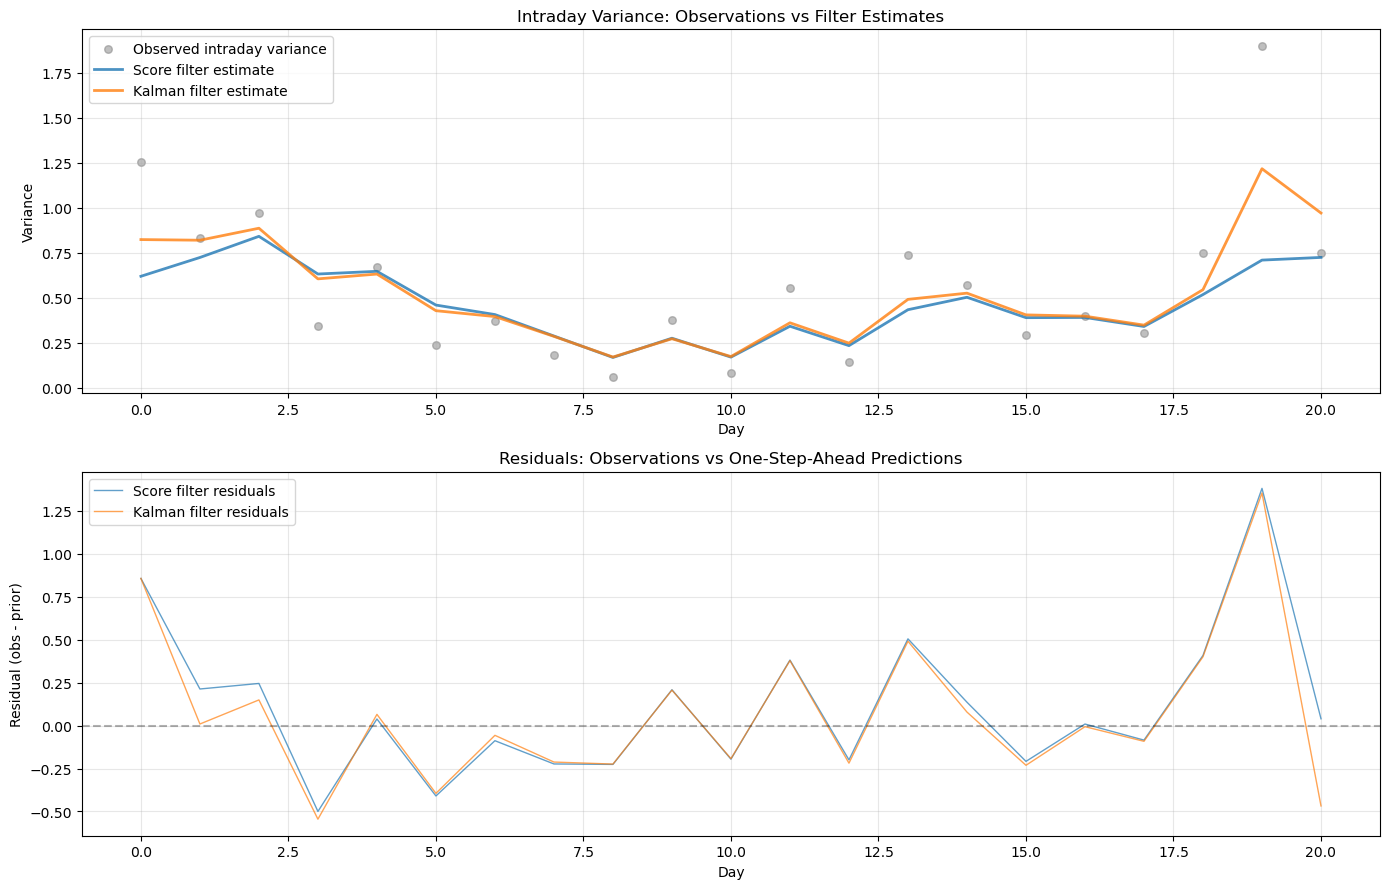


=== Filter Comparison ===
Score filter:  phi=0.990, kappa=0.554, sigma=0.3314, nu=6
Kalman filter: phi=0.990, kappa=0.500, sigma=0.4545

Mean residual:
  Score:  0.109122
  Kalman: 0.064405
Std residual:
  Score:  0.424690
  Kalman: 0.437503


In [14]:
# Plot results on actual intraday variance data
t = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Time series: observations and filter estimates
axes[0].scatter(t, y, label="Observed intraday variance", alpha=0.5, s=30, color="gray")
axes[0].plot(t, score_filter.mu, label="Score filter estimate", linewidth=2, alpha=0.8)
axes[0].plot(
    t, kalman_filter.mu, label="Kalman filter estimate", linewidth=2, alpha=0.8
)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Variance")
axes[0].set_title("Intraday Variance: Observations vs Filter Estimates")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals (innovations)
residuals_score = [y_t - mu_t for y_t, mu_t in zip(y, score_filter.mu_prior)]
residuals_kalman = [y_t - mu_t for y_t, mu_t in zip(y, kalman_filter.mu_prior)]
axes[1].plot(t, residuals_score, label="Score filter residuals", linewidth=1, alpha=0.7)
axes[1].plot(
    t, residuals_kalman, label="Kalman filter residuals", linewidth=1, alpha=0.7
)
axes[1].axhline(0, color="k", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Residual (obs - prior)")
axes[1].set_title("Residuals: Observations vs One-Step-Ahead Predictions")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"\n=== Filter Comparison ===")
print(
    f"Score filter:  phi={best_params_score['phi']:.3f}, kappa={best_params_score['kappa']:.3f}, sigma={best_params_score['sigma']:.4f}, nu={best_params_score['nu']}"
)

# Kalman filter has no 'nu'
print(
    f"Kalman filter: phi={best_params_kalman['phi']:.3f}, kappa={best_params_kalman['kappa']:.3f}, sigma={best_params_kalman['sigma']:.4f}"
)

print(f"\nMean residual:")
print(f"  Score:  {np.mean(residuals_score):.6f}")
print(f"  Kalman: {np.mean(residuals_kalman):.6f}")
print(f"Std residual:")
print(f"  Score:  {np.std(residuals_score):.6f}")
print(f"  Kalman: {np.std(residuals_kalman):.6f}")